# Avaliação — DRIVE

Notebook fino reusando `utils_eval.py` (loader unificado) e `utils.py` (plot/aggregação legado).

**Observação:** Zero-shot real. **Scratch ausente** (inferência ainda não rodou para multi_train_scratch_drive_*). Os labels UNet18/UNet50 não aparecerão até que metrics_stats.csv seja gerado.

## Legenda das nomenclaturas de modelos

Cada `model_type` codifica três informações: **arquitetura**, **origem dos pesos iniciais** e **regime de treino**.

| Label                  | Arquitetura            | Pesos iniciais          | Regime                  | Stage         |
|------------------------|------------------------|-------------------------|-------------------------|---------------|
| `UNet18`               | U-Net (encoder ResNet-18) | Aleatórios (Kaiming)   | Treino do zero          | `scratch`     |
| `UNet50`               | U-Net (encoder ResNet-50) | Aleatórios (Kaiming)   | Treino do zero          | `scratch`     |
| `VSUNet18`             | U-Net (encoder ResNet-18) | Pré-treinados em **VessShape** | Fine-tuning no dataset alvo | `finetune` |
| `VSUNet50`             | U-Net (encoder ResNet-50) | Pré-treinados em **VessShape** | Fine-tuning no dataset alvo | `finetune` |
| `IN-UNet18`            | U-Net (encoder ResNet-18) | Pré-treinados em **ImageNet** | Fine-tuning no dataset alvo | `finetune` |
| `IN-UNet50`            | U-Net (encoder ResNet-50) | Pré-treinados em **ImageNet** | Fine-tuning no dataset alvo | `finetune` |
| `LiteMedSAM-FT`        | LiteMedSAM (encoder ViT leve do MedSAM) | Pré-treinados em **MedSAM** (LiteMedSAM checkpoint) | Fine-tuning no dataset alvo | `finetune` |
| `Zero-Shot VSUNet18`   | U-Net (encoder ResNet-18) | Pré-treinados em **VessShape** | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `Zero-Shot VSUNet50`   | U-Net (encoder ResNet-50) | Pré-treinados em **VessShape** | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `... (mock)`           | —                      | —                       | Placeholder com `NaN`   | `zero_shot`   |

**Convenções:**
- `VS` = pré-treino em **VessShape** (dataset sintético próprio do projeto).
- `IN-` = pré-treino em **ImageNet**.
- `-FT` = fine-tuning a partir de checkpoint pré-treinado.
- `Zero-Shot` = nenhum fine-tuning no dataset alvo (`num_samples = 0`).
- Sufixo ` (mock)` = linha placeholder gerada por `utils_eval.generate_mock_zero_shot` quando o CSV de zero-shot real ainda não existe (DCA1 e OCTA2D); aparece com `NaN` em todas as métricas e é identificada por `is_mock=True`.

**Eixo de comparação do paper:**
- `UNet*` (scratch) vs `IN-UNet*` (ImageNet) vs `VSUNet*` (VessShape) → mede o ganho do pré-treino em VessShape sobre as alternativas.
- `Zero-Shot VSUNet*` em `num_samples = 0` → mede a transferência sem fine-tuning.
- `LiteMedSAM-FT` → baseline de modelo de segmentação médica de larga escala.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
from utils_eval import (
    load_dataset_results,
    load_dataset_per_image,
    save_result_matrices,
    build_summary_table,
    default_line_styles_7way,
    report_coverage,
    RESULTS_DIR,
    FIGURES_DIR,
    ensure_output_dirs,
)

ensure_output_dirs()  # cria results/ e figures/ se necessário
from utils import plot_mean_dice_score

## 1. Carregar dados

In [2]:
DATASET = 'drive'
MOCK_ZS = False

df = load_dataset_results(DATASET, root='..', mock_zero_shot=MOCK_ZS)
print('shape =', df.shape)
df['model_type'].value_counts()

shape = (677, 16)


model_type
LiteMedSAM-FT         135
IN-UNet18             135
VSUNet18              135
IN-UNet50             135
VSUNet50              135
Zero-Shot VSUNet18      1
Zero-Shot VSUNet50      1
Name: count, dtype: int64

## Matrizes de resultados (intermediárias)

Salvas em `results/` via `save_result_matrices`. Três regimes × duas granularidades:
- `<ds>_few_shot_results[_per_image].csv` — só few-shot (scratch + finetune).
- `<ds>_zero_shot_results[_per_image].csv` — só zero-shot.
- `<ds>_all_results[_per_image].csv` — few + zero-shot (matriz-base).

Granularidade média-por-run (sufixo vazio) e por-imagem (`_per_image`). Zero-shot mock não tem per-image.

In [3]:
# Matriz média-por-run (df já carregado) — few-shot / zero-shot / all
paths_run = save_result_matrices(df, DATASET)

# Matriz por imagem — few-shot / zero-shot / all
df_per_image = load_dataset_per_image(DATASET, root='..')
paths_img = save_result_matrices(df_per_image, DATASET, suffix='_per_image')

print('run-mean :', df.shape, '->', {k: __import__('os').path.basename(v) for k, v in paths_run.items()})
print('per-image:', df_per_image.shape, '->', {k: __import__('os').path.basename(v) for k, v in paths_img.items()})

run-mean : (677, 16) -> {'few_shot': 'drive_few_shot_results.csv', 'zero_shot': 'drive_zero_shot_results.csv', 'all': 'drive_all_results.csv'}
per-image: (13540, 17) -> {'few_shot': 'drive_few_shot_results_per_image.csv', 'zero_shot': 'drive_zero_shot_results_per_image.csv', 'all': 'drive_all_results_per_image.csv'}


## 2. Sanidade — cobertura por modelo / stage

In [4]:
coverage = report_coverage(df)
print('Stages presentes:', sorted(df['stage'].unique()))
if df['is_mock'].any():
    n_mock = int(df['is_mock'].sum())
    print(f'[INFO] {n_mock} linha(s) zero-shot MOCK (NaN). Substituir quando inferência real estiver pronta.')

expected = {'UNet18','UNet50','VSUNet18','VSUNet50','IN-UNet18','IN-UNet50','LiteMedSAM-FT'}
missing = expected - set(df['model_type'].unique())
if missing:
    print(f'[INFO] model_types ausentes (esperado em datasets completos): {sorted(missing)}')
coverage

Stages presentes: ['finetune', 'zero_shot']
[INFO] model_types ausentes (esperado em datasets completos): ['UNet18', 'UNet50']


,,count,min,max
model_type,stage,,,
IN-UNet18,finetune,135,1,16
IN-UNet50,finetune,135,1,16
LiteMedSAM-FT,finetune,135,1,16
VSUNet18,finetune,135,1,16
VSUNet50,finetune,135,1,16
Zero-Shot VSUNet18,zero_shot,1,0,0
Zero-Shot VSUNet50,zero_shot,1,0,0


## 3. Resumo (mean ± std) em num_samples ∈ [0, 1, 16]

In [6]:
SAMPLE_FILTER = [0, 1, 16]
summary = build_summary_table(df, sample_filter=SAMPLE_FILTER)
summary.to_csv(os.path.join(RESULTS_DIR, 'drive_results_summary.csv'), index=False)
summary

,model_type,num_samples,mean_Accuracy,std_Accuracy,mean_IoU,std_IoU,mean_Precision,std_Precision,mean_Recall,std_Recall,mean_Dice,std_Dice,mean_AUC,std_AUC
0,IN-UNet18,1,0.924522,0.018587,0.565726,0.041119,0.726824,0.089152,0.749020,0.092734,0.719935,0.035032,0.943526,0.011625
1,IN-UNet18,16,0.948861,0.000856,0.659029,0.003806,0.813478,0.007208,0.781011,0.005619,0.794220,0.002767,0.966919,0.001450
2,IN-UNet50,1,0.932597,0.007055,0.582253,0.031809,0.751483,0.071638,0.743147,0.089875,0.734667,0.026521,0.950074,0.006966
3,IN-UNet50,16,0.947875,0.000247,0.656122,0.001494,0.803547,0.003787,0.785580,0.004919,0.792146,0.001092,0.965390,0.000402
4,LiteMedSAM-FT,1,0.927434,0.009426,0.509579,0.075692,0.787639,0.046416,0.604297,0.106265,0.665348,0.074923,0.913332,0.044308
5,LiteMedSAM-FT,16,0.948947,0.000399,0.644917,0.003036,0.849580,0.003572,0.732683,0.005301,0.783711,0.002272,0.969295,0.000914
6,VSUNet18,1,0.940678,0.002511,0.615336,0.009168,0.781870,0.022504,0.749461,0.019134,0.761387,0.007053,0.947636,0.004987
7,VSUNet18,16,0.950331,0.000177,0.663093,0.001027,0.829245,0.002682,0.772302,0.002661,0.797156,0.000758,0.966524,0.000497
8,VSUNet50,1,0.937536,0.006533,0.604616,0.018896,0.766793,0.048289,0.751262,0.042900,0.752772,0.014994,0.948240,0.005162
9,VSUNet50,16,0.951326,0.000226,0.665807,0.001118,0.840976,0.001956,0.766328,0.001739,0.799093,0.000811,0.968581,0.000403


## 4. Plot principal — Dice por # samples

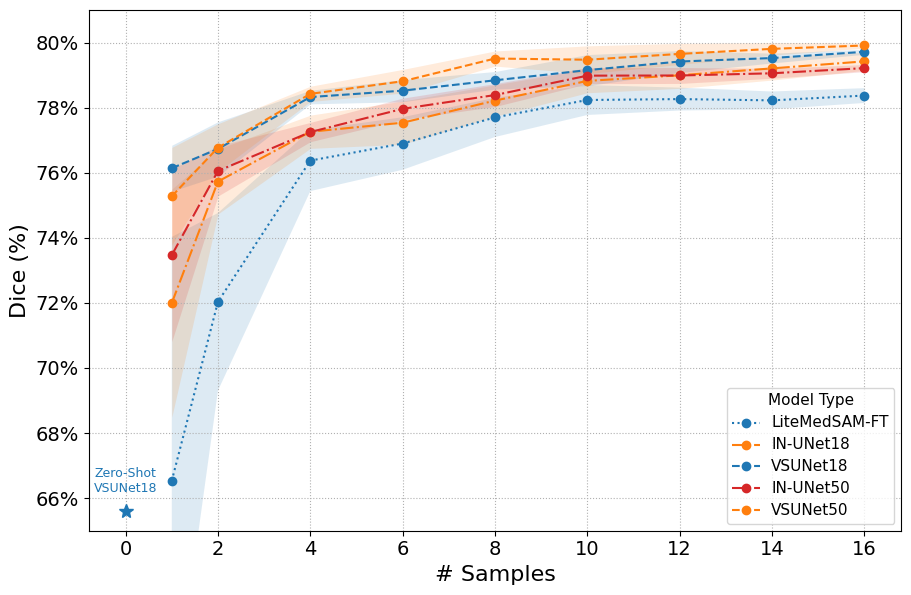

In [7]:
line_styles = default_line_styles_7way()

plot_mean_dice_score(
    df,
    dataset_name='DRIVE',
    hue='model_type',
    x_data='num_samples',
    y_data='Dice',
    y_limits=(0.65, 0.81),
    line_styles=line_styles,
    annotate_zero_shot=True,
    title='',
    legend_title='Model Type',
    xlabel='# Samples',
    percentage=True,
    save_path=os.path.join(FIGURES_DIR, 'drive.svg'),
    font_sizes={
        'title': 16,
        'xlabel': 16,
        'ylabel': 16,
        'xaxis': 14,
        'yaxis': 14,
        'legend': 11,
        'zero_shot_annotation': 9,
        'zero_shot_marker': 10,
    },
    figsize=(9, 6),
    legend_loc='lower right',
    share_zero_shot_color_with='finetuned',
)

## 5. Subplots focados — família ResNet18 e ResNet50

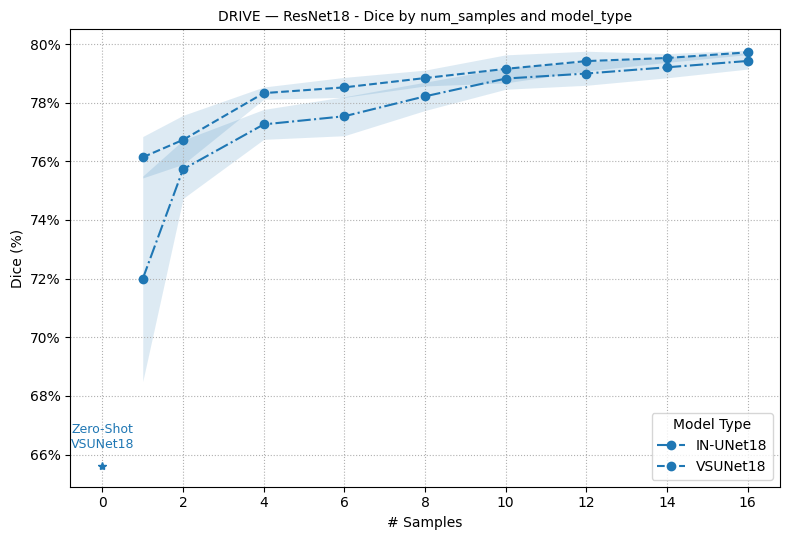

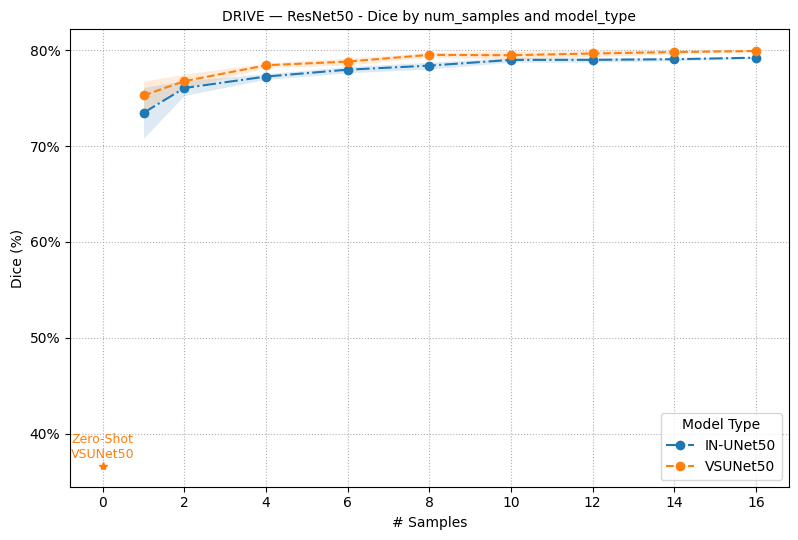

In [8]:
for fam_name, fam_labels in [
    ('ResNet18', ['UNet18','VSUNet18','IN-UNet18','Zero-Shot VSUNet18','Zero-Shot VSUNet18 (mock)']),
    ('ResNet50', ['UNet50','VSUNet50','IN-UNet50','Zero-Shot VSUNet50','Zero-Shot VSUNet50 (mock)']),
]:
    sub = df[df['model_type'].isin(fam_labels)]
    if sub.empty:
        print(f'[INFO] Sem dados para {fam_name}.')
        continue
    plot_mean_dice_score(
        sub,
        dataset_name='DRIVE — ' + fam_name,
        hue='model_type',
        x_data='num_samples',
        y_data='Dice',
        line_styles=line_styles,
        annotate_zero_shot=True,
        legend_title='Model Type',
        xlabel='# Samples',
        percentage=True,
        save_path=os.path.join(FIGURES_DIR, 'drive_' + fam_name.lower() + '.svg'),
        figsize=(8, 5.5),
        legend_loc='lower right',
        share_zero_shot_color_with='finetuned',
    )